<a href="https://colab.research.google.com/github/brvndon266/MAE249_Soft_Robotics/blob/main/Homework_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem 1 - Part B
---

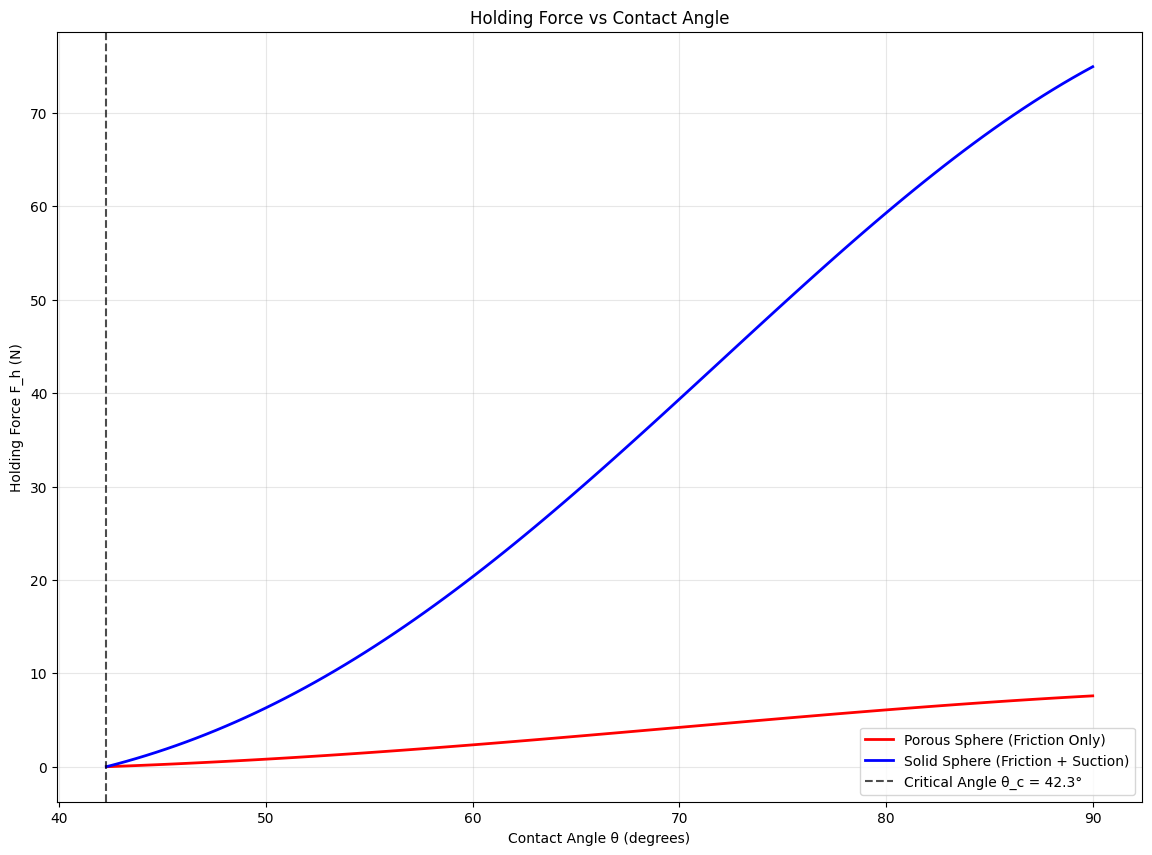

Critical angle θ_c = 42.27°
Maximum holding force (porous): 7.59 N
Maximum holding force (solid): 74.95 N


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Given parameters
mu = 1.1
sigma_star = 54e3  # Pa
d = 1.07e-3  # m
R = 19e-3  # m

# Critical angle
theta_c = np.arctan(1/mu)

# Create theta range from theta_c to pi/2
theta = np.linspace(theta_c, np.pi/2, 100)

# Porous sphere (friction only)
F_h_porous = 2 * np.pi * R * d * sigma_star * (mu * np.sin(theta) - np.cos(theta)) * np.sin(theta)**2

# Solid sphere (friction + suction)
F_h_solid = (np.pi * R**2 * sigma_star * (mu * np.sin(theta) - np.cos(theta)) * np.sin(theta)**3 *
             (1 + (2*d)/(R * np.sin(theta))))

# Convert to Newtons and plot
plt.figure(figsize=(14, 10))
plt.plot(np.degrees(theta), F_h_porous, 'r-', linewidth=2, label='Porous Sphere (Friction Only)')
plt.plot(np.degrees(theta), F_h_solid, 'b-', linewidth=2, label='Solid Sphere (Friction + Suction)')
plt.axvline(np.degrees(theta_c), color='k', linestyle='--', alpha=0.7, label=f'Critical Angle θ_c = {np.degrees(theta_c):.1f}°')

plt.xlabel('Contact Angle θ (degrees)')
plt.ylabel('Holding Force F_h (N)')
plt.title('Holding Force vs Contact Angle')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Critical angle θ_c = {np.degrees(theta_c):.2f}°")
print(f"Maximum holding force (porous): {np.max(F_h_porous):.2f} N")
print(f"Maximum holding force (solid): {np.max(F_h_solid):.2f} N")

Problem 1 - Part C
---

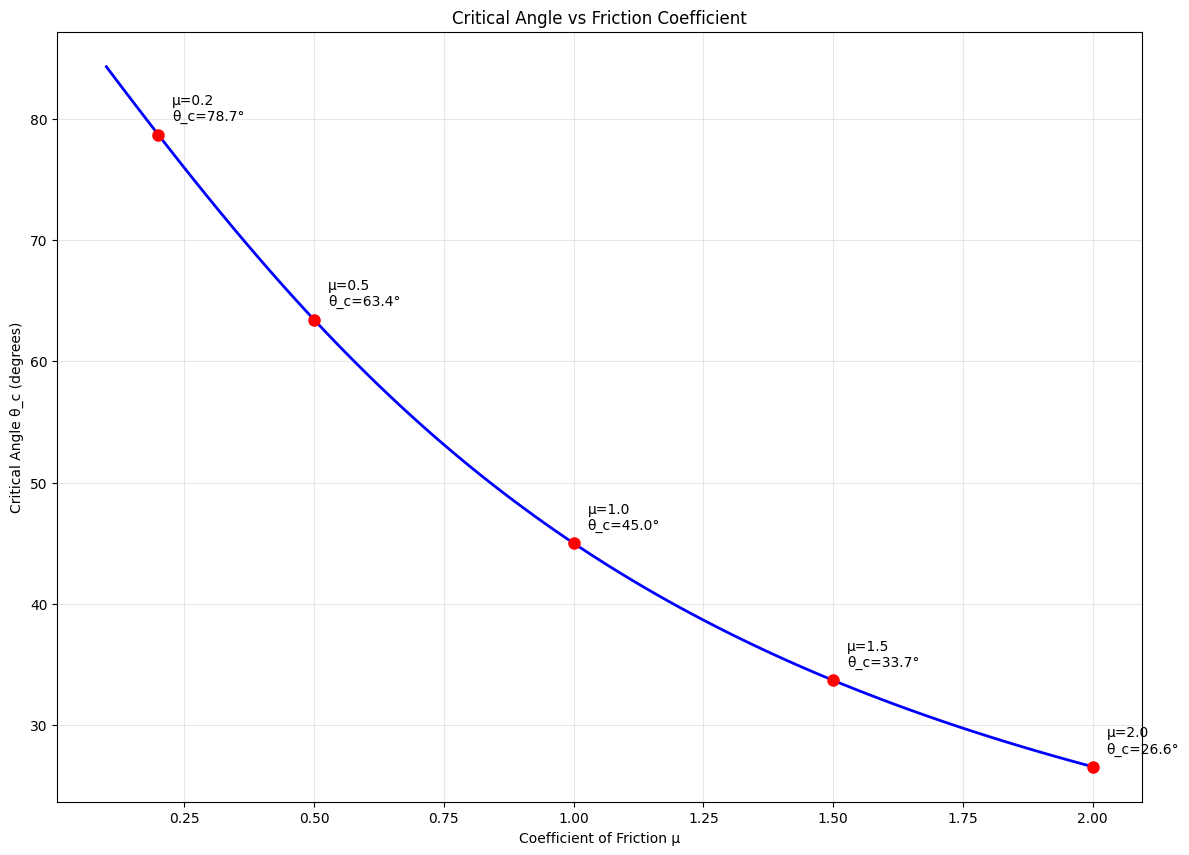

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Physically achievable range of friction coefficients
# Rubber on various surfaces can achieve μ = 0.1 to 2.0+
mu_range = np.linspace(0.1, 2.0, 100)
theta_c_range = np.arctan(1/mu_range)

plt.figure(figsize=(14, 10))
plt.plot(mu_range, np.degrees(theta_c_range), 'b-', linewidth=2)
plt.xlabel('Coefficient of Friction μ')
plt.ylabel('Critical Angle θ_c (degrees)')
plt.title('Critical Angle vs Friction Coefficient')
plt.grid(True, alpha=0.3)

# Mark some realistic values
realistic_mu = [0.2, 0.5, 1.0, 1.5, 2.0]
for mu_val in realistic_mu:
    theta_val = np.degrees(np.arctan(1/mu_val))
    plt.plot(mu_val, theta_val, 'ro', markersize=8)
    plt.annotate(f'μ={mu_val}\nθ_c={theta_val:.1f}°',
                (mu_val, theta_val),
                xytext=(10, 10), textcoords='offset points')

plt.show()

Problem 1 - Part D
---


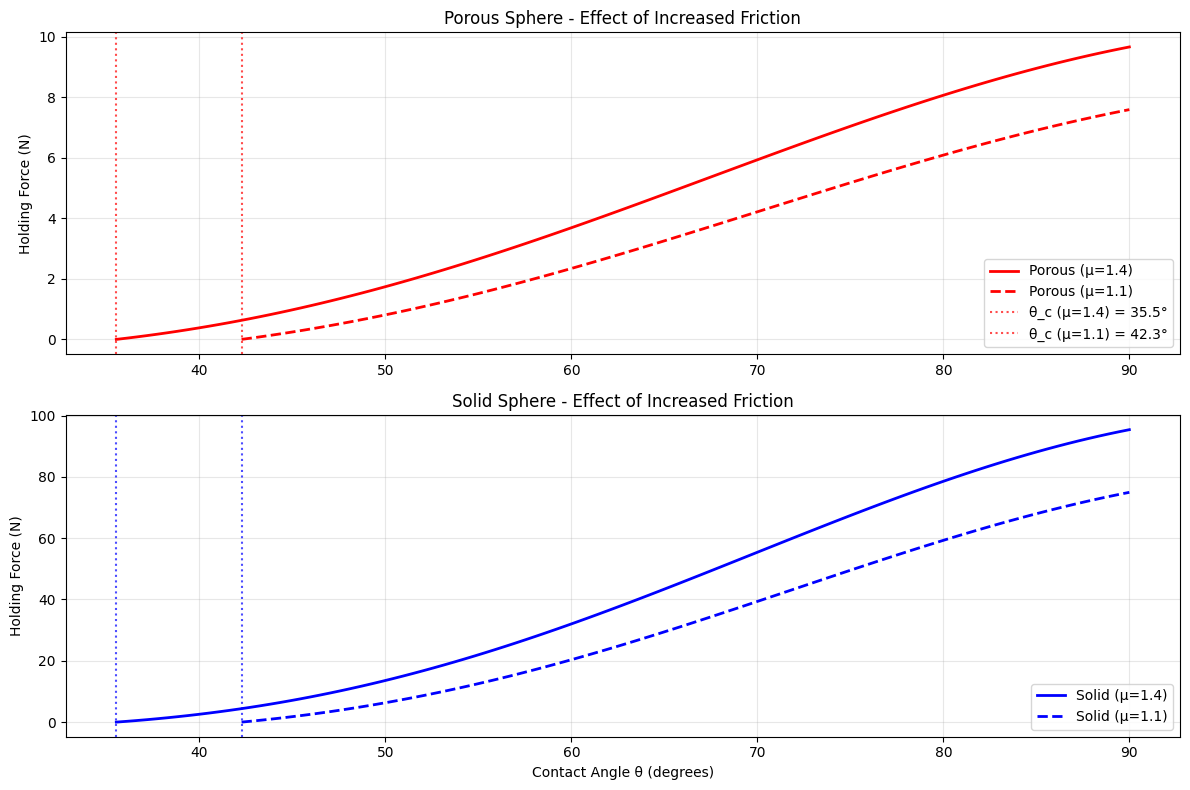

Critical angle reduction: 6.7°
Maximum force increase (porous): 27.3%
Maximum force increase (solid): 27.3%


In [3]:
# Parameters with increased friction
mu_high = 1.4
sigma_star = 54e3  # Pa
d = 1.07e-3  # m
R = 19e-3  # m

# New critical angle
theta_c_high = np.arctan(1/mu_high)

# Theta range from new critical angle to pi/2
theta_high = np.linspace(theta_c_high, np.pi/2, 100)

# Calculate holding forces
F_h_porous_high = 2 * np.pi * R * d * sigma_star * (mu_high * np.sin(theta_high) - np.cos(theta_high)) * np.sin(theta_high)**2
F_h_solid_high = (np.pi * R**2 * sigma_star * (mu_high * np.sin(theta_high) - np.cos(theta_high)) * np.sin(theta_high)**3 *
                  (1 + (2*d)/(R * np.sin(theta_high))))

# Compare with original μ = 1.1
mu_orig = 1.1
theta_c_orig = np.arctan(1/mu_orig)
theta_orig = np.linspace(theta_c_orig, np.pi/2, 100)

F_h_porous_orig = 2 * np.pi * R * d * sigma_star * (mu_orig * np.sin(theta_orig) - np.cos(theta_orig)) * np.sin(theta_orig)**2
F_h_solid_orig = (np.pi * R**2 * sigma_star * (mu_orig * np.sin(theta_orig) - np.cos(theta_orig)) * np.sin(theta_orig)**3 *
                  (1 + (2*d)/(R * np.sin(theta_orig))))

# Plot comparison
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(np.degrees(theta_high), F_h_porous_high, 'r-', linewidth=2, label='Porous (μ=1.4)')
plt.plot(np.degrees(theta_orig), F_h_porous_orig, 'r--', linewidth=2, label='Porous (μ=1.1)')
plt.axvline(np.degrees(theta_c_high), color='r', linestyle=':', alpha=0.7, label=f'θ_c (μ=1.4) = {np.degrees(theta_c_high):.1f}°')
plt.axvline(np.degrees(theta_c_orig), color='r', linestyle=':', alpha=0.7, label=f'θ_c (μ=1.1) = {np.degrees(theta_c_orig):.1f}°')
plt.ylabel('Holding Force (N)')
plt.title('Porous Sphere - Effect of Increased Friction')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(np.degrees(theta_high), F_h_solid_high, 'b-', linewidth=2, label='Solid (μ=1.4)')
plt.plot(np.degrees(theta_orig), F_h_solid_orig, 'b--', linewidth=2, label='Solid (μ=1.1)')
plt.axvline(np.degrees(theta_c_high), color='b', linestyle=':', alpha=0.7)
plt.axvline(np.degrees(theta_c_orig), color='b', linestyle=':', alpha=0.7)
plt.xlabel('Contact Angle θ (degrees)')
plt.ylabel('Holding Force (N)')
plt.title('Solid Sphere - Effect of Increased Friction')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Critical angle reduction: {np.degrees(theta_c_orig - theta_c_high):.1f}°")
print(f"Maximum force increase (porous): {((np.max(F_h_porous_high)/np.max(F_h_porous_orig))-1)*100:.1f}%")
print(f"Maximum force increase (solid): {((np.max(F_h_solid_high)/np.max(F_h_solid_orig))-1)*100:.1f}%")

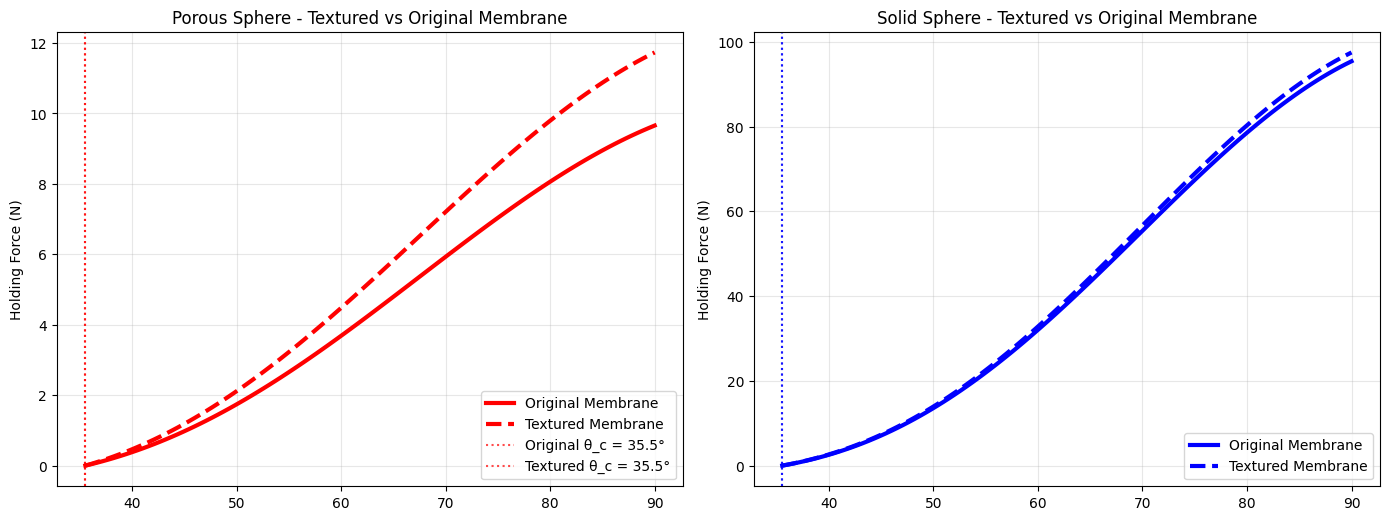

=== TEXTURED MEMBRANE EFFECTS ===
Critical angle reduction: 0.0°
Effective contact width increase: 21%

Maximum holding force at θ = 90°:
Porous sphere - Original: 9.66 N
Porous sphere - Textured: 11.73 N

Solid sphere - Original: 95.40 N
Solid sphere - Textured: 97.47 N


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Base parameters from the paper
sigma_star = 54e3  # Pa
d = 1.07e-3  # m
R = 19e-3  # m
mu_original = 1.4

# Textured membrane parameters
mu_textured = 1.4  # Increased effective friction
d_effective = 1.3e-3  # Increased effective contact width due to better sealing

def holding_force_porous(theta, mu, d_eff):
    """Holding force for porous sphere (friction only)"""
    return 2 * np.pi * R * d_eff * sigma_star * (mu * np.sin(theta) - np.cos(theta)) * np.sin(theta)**2

def holding_force_solid(theta, mu, d_eff):
    """Holding force for solid sphere (friction + suction)"""
    return (np.pi * R**2 * sigma_star * (mu * np.sin(theta) - np.cos(theta)) * np.sin(theta)**3 *
            (1 + (2*d_eff)/(R * np.sin(theta))))

# Calculate critical angles
theta_c_original = np.arctan(1/mu_original)
theta_c_textured = np.arctan(1/mu_textured)

# Create theta ranges
theta_original = np.linspace(theta_c_original, np.pi/2, 100)
theta_textured = np.linspace(theta_c_textured, np.pi/2, 100)

# Calculate holding forces
F_porous_orig = holding_force_porous(theta_original, mu_original, d)
F_solid_orig = holding_force_solid(theta_original, mu_original, d)

F_porous_text = holding_force_porous(theta_textured, mu_textured, d_effective)
F_solid_text = holding_force_solid(theta_textured, mu_textured, d_effective)

# Plot comparison
plt.figure(figsize=(14, 10))

# Porous sphere comparison
plt.subplot(2, 2, 1)
plt.plot(np.degrees(theta_original), F_porous_orig, 'r-', linewidth=3, label='Original Membrane')
plt.plot(np.degrees(theta_textured), F_porous_text, 'r--', linewidth=3, label='Textured Membrane')
plt.axvline(np.degrees(theta_c_original), color='r', linestyle=':', alpha=0.7,
           label=f'Original θ_c = {np.degrees(theta_c_original):.1f}°')
plt.axvline(np.degrees(theta_c_textured), color='r', linestyle=':', alpha=0.7,
           label=f'Textured θ_c = {np.degrees(theta_c_textured):.1f}°')
plt.ylabel('Holding Force (N)')
plt.title('Porous Sphere - Textured vs Original Membrane')
plt.legend()
plt.grid(True, alpha=0.3)

# Solid sphere comparison
plt.subplot(2, 2, 2)
plt.plot(np.degrees(theta_original), F_solid_orig, 'b-', linewidth=3, label='Original Membrane')
plt.plot(np.degrees(theta_textured), F_solid_text, 'b--', linewidth=3, label='Textured Membrane')
plt.axvline(np.degrees(theta_c_original), color='b', linestyle=':', alpha=0.7)
plt.axvline(np.degrees(theta_c_textured), color='b', linestyle=':', alpha=0.7)
plt.ylabel('Holding Force (N)')
plt.title('Solid Sphere - Textured vs Original Membrane')
plt.legend()
plt.grid(True, alpha=0.3)

# Force enhancement percentage
theta_common = np.linspace(max(theta_c_original, theta_c_textured), np.pi/2, 100)
F_porous_orig_common = holding_force_porous(theta_common, mu_original, d)
F_porous_text_common = holding_force_porous(theta_common, mu_textured, d_effective)
F_solid_orig_common = holding_force_solid(theta_common, mu_original, d)
F_solid_text_common = holding_force_solid(theta_common, mu_textured, d_effective)


plt.tight_layout()
plt.show()

# Quantitative analysis
print("=== TEXTURED MEMBRANE EFFECTS ===")
print(f"Critical angle reduction: {np.degrees(theta_c_original - theta_c_textured):.1f}°")
print(f"Effective contact width increase: {(d_effective/d - 1)*100:.0f}%")

max_theta = np.pi/2
F_porous_max_orig = holding_force_porous(max_theta, mu_original, d)
F_porous_max_text = holding_force_porous(max_theta, mu_textured, d_effective)
F_solid_max_orig = holding_force_solid(max_theta, mu_original, d)
F_solid_max_text = holding_force_solid(max_theta, mu_textured, d_effective)

print(f"\nMaximum holding force at θ = 90°:")
print(f"Porous sphere - Original: {F_porous_max_orig:.2f} N")
print(f"Porous sphere - Textured: {F_porous_max_text:.2f} N")

print(f"\nSolid sphere - Original: {F_solid_max_orig:.2f} N")
print(f"Solid sphere - Textured: {F_solid_max_text:.2f} N")


